In [ ]:
# Jak to spoustim?

# https://www.idiap.ch/software/bob/docs/bob/docs/stable/install.html
# mamba create --name bob --override-channels   -c https://www.idiap.ch/software/bob/conda   -c conda-forge   python=3.10 bob.bio.vein ipykernel opencv
# mamba activate bob

# Vytvoreni kernelu
# python -m ipykernel install --user --name=bob --display-name "bob.bio.vein kernel

# Potom mamba activate base a odtud spoustim python notebook:
# jupyter notebook --no-browser --ip=0.0.0.0 --port=8888

# napravo nahore vyberu kernel
# hotovo

# !!!!!! Pokud to pise problem s scikit learn safe_tags, staci spustit bunku znovu, deje se to jen po nacteni kernelu !!!!!!

In [1]:
import zipfile
import os

zip_path = "dataset.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset rozbalen do složky:", extract_path)

Dataset rozbalen do složky: dataset


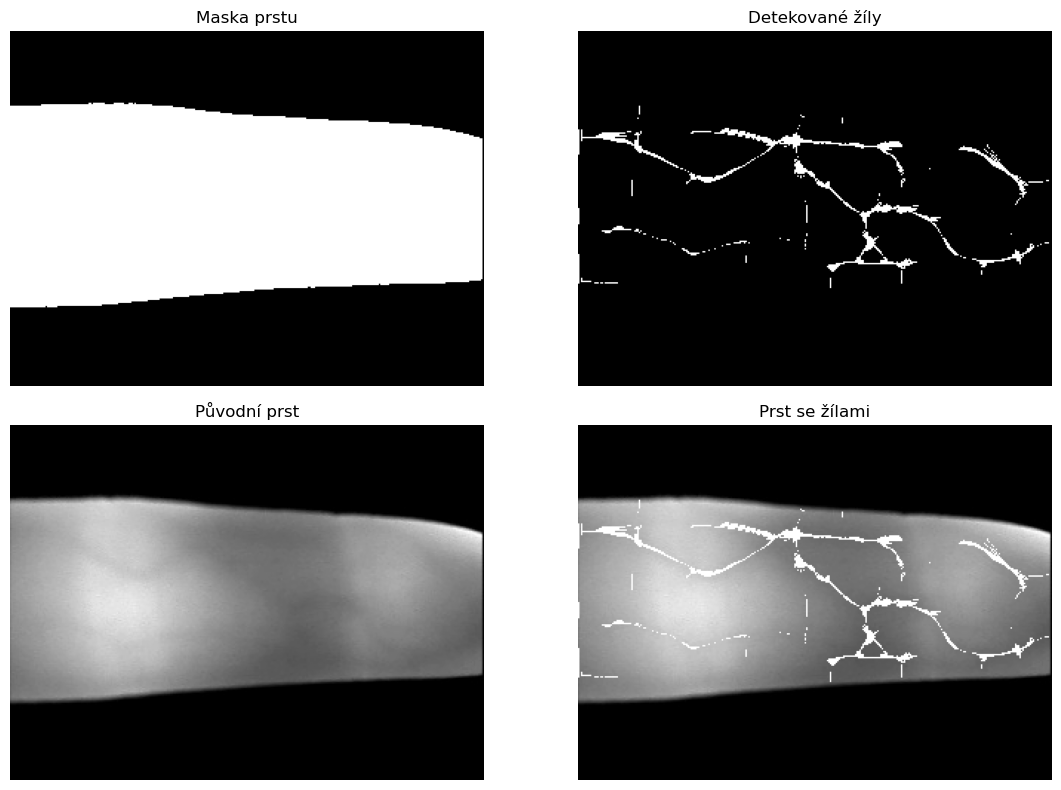

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from bob.bio.vein.extractor import MaximumCurvature, RepeatedLineTracking

mc_extractor = MaximumCurvature()

# aplikace MC
def apply_maximum_curvature(img, mask):
    features = mc_extractor((img.astype(np.float32), mask))
    thresh = threshold_otsu(features)
    binary = (features > thresh).astype(np.uint8) * 255
    return binary

# vytvoření overlay
def create_overlay(img, binary):
    ovr = img.copy()
    ovr[binary > 0] = np.max(img)
    return ovr

# načtení obrázků
# IMG_DIR = "dataset/Finger_Vein_Database"
# IMG_DIR = "dataset/FV_USM"
IMG_DIR = "dataset/MMCBNU_6000"

files = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")]
files.sort()

# obrázek
first_img_path = os.path.join(IMG_DIR, files[1])

# převod na float32
img = Image.open(first_img_path).convert("L")
image = np.array(img, dtype=np.float32)

# maska prstu
mask_thresh = threshold_otsu(image)
finger_mask = (image > mask_thresh).astype(np.uint8)

# aplikace Maximum Curvature
binary_orig = apply_maximum_curvature(image, finger_mask)

overlay = create_overlay(image, binary_orig)

# vizualizace
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Maska prstu")
plt.imshow(finger_mask, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Detekované žíly")
plt.imshow(binary_orig, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Původní prst")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Prst se žílami")
plt.imshow(overlay, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

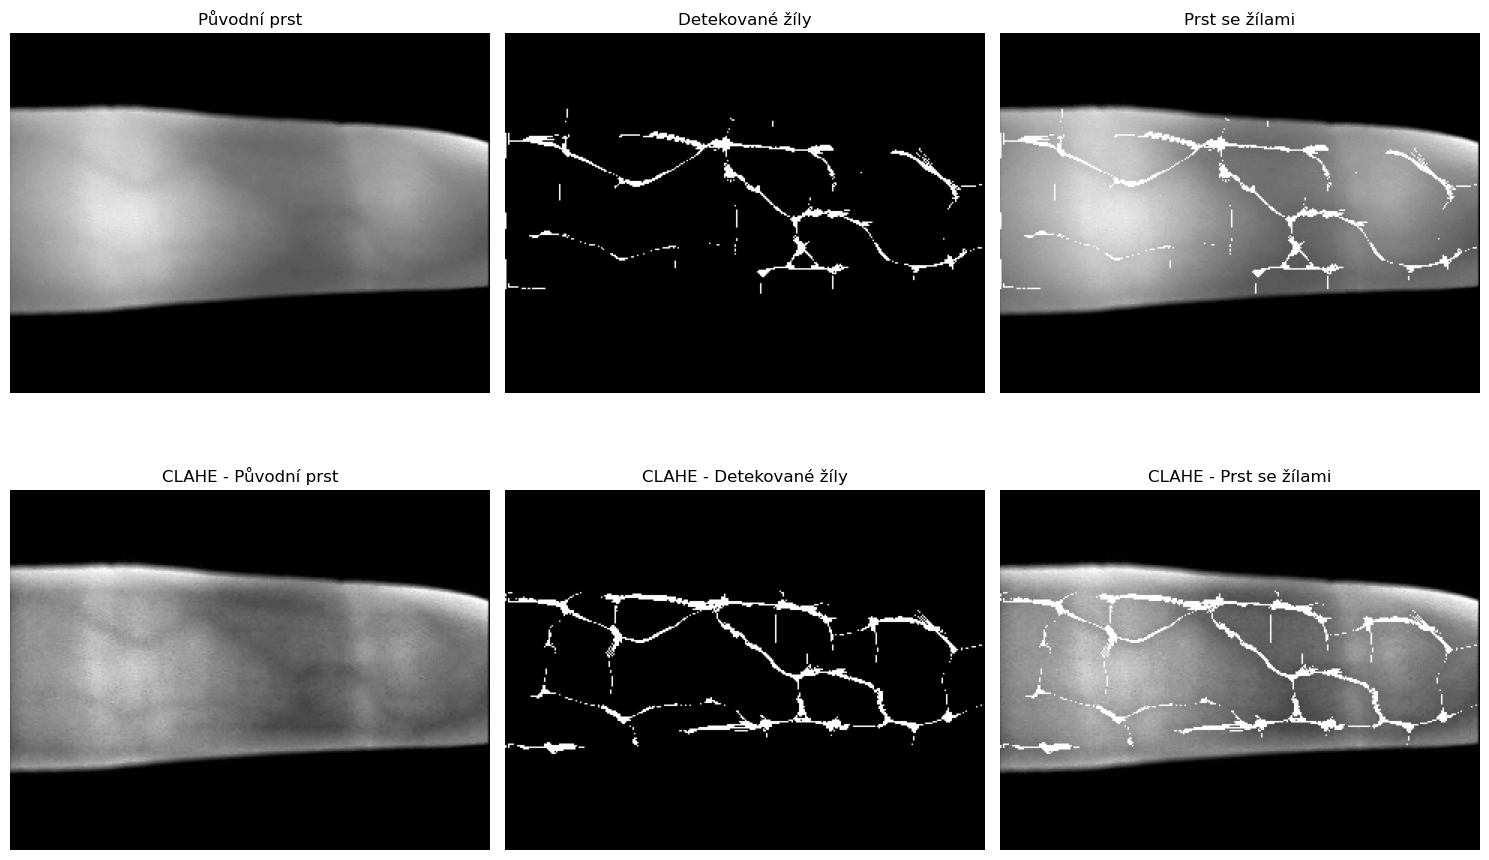

In [3]:
import cv2
from scipy.ndimage import gaussian_filter, median_filter
from skimage import exposure

# OpenCV CLAHE
clahe = cv2.createCLAHE(clipLimit=2.1, tileGridSize=(16, 16))
image_clahe = clahe.apply(image.astype(np.uint8))
binary_clahe = apply_maximum_curvature(image_clahe, finger_mask)
overlay_clahe = create_overlay(image_clahe, binary_clahe)

# vizualizace
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.title("Původní prst")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Detekované žíly")
plt.imshow(binary_orig, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Prst se žílami")
plt.imshow(overlay, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("CLAHE - Původní prst")
plt.imshow(image_clahe, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("CLAHE - Detekované žíly")
plt.imshow(binary_clahe, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("CLAHE - Prst se žílami")
plt.imshow(overlay_clahe, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()